# Previsão de Volumetria de Produção da Transportadora - Modelo Multivariado
### Modelo de Séries Temporais com XGBoost e LightGBM (com Lags e Hiperparâmetros por Filial)

Este notebook prevê a **volumetria diária de produção** de **todas as filiais** de uma transportadora de varejo,
com horizonte de **30 dias**, para apoiar o planejamento de **mão de obra**.

**Principais características:**
- Modelo multivariado: previsão para 13 filiais simultaneamente
- Tuning de hiperparâmetros específico por filial
- Features de calendário e eventos (Calendario_v3)
- Lags da série temporal (D-1, D-2, D-3, D-7, médias móveis)
- Variáveis regressoras (feriados, Black Friday, etc.)
- Previsão recursiva com lags dinâmicos

**Estrutura do notebook:**

1. Carregamento e preparação dos dados (multivariado)
2. Análise exploratória multivariada (por filial)
3. Engenharia de features (lags por filial + regressores)
4. Modelagem com tuning de hiperparâmetros por filial
5. Validação e avaliação por filial
6. Previsão futura (30 dias) com lags recursivos
7. Storytelling e visualizações finais
8. Exportação dos resultados


## Sumário

- [1. Carregamento e preparação dos dados](#carregamento)
- [2. Análise exploratória multivariada](#eda)
- [3. Engenharia de features (lags por filial + regressores)](#features)
- [4. Modelagem com tuning de hiperparâmetros por filial](#modelagem)
- [5. Validação e avaliação](#validacao)
- [6. Previsão futura (30 dias)](#previsao)
- [7. Storytelling e visualizações finais](#storytelling)
- [8. Exportação dos resultados](#exportacao)


In [23]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Modelos
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

# Configurações de visualização
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
sns.set_style("whitegrid")


<a id="carregamento"></a>
## 1. Carregamento e preparação dos dados

Nesta seção carregamos:
- Histórico completo de produção diária de todas as filiais (`Historico_Completo.csv`)
- Calendário de feriados e eventos (`Calendario_v3.csv`)

Em seguida, fazemos a limpeza de colunas, conversão de tipos, merge dos datasets e validação inicial.


In [24]:
# Caminhos dos arquivos
PATH_HIST = "Historico_Completo.csv"
PATH_CAL = "Calendario_v3.csv"

# Leitura com encoding e separador apropriados
print("Carregando dados históricos...")
hist = pd.read_csv(PATH_HIST, sep=";", encoding="latin1")
print(f"Histórico carregado: {len(hist)} registros")

print("\nCarregando calendário...")
cal = pd.read_csv(PATH_CAL, sep=";", encoding="latin1")
print(f"Calendário carregado: {len(cal)} registros")

# Conversão de datas
hist['Data'] = pd.to_datetime(hist['Data'], dayfirst=True)
cal['Data'] = pd.to_datetime(cal['Data'], dayfirst=True)

# Limpeza de nomes de colunas do calendário (remover espaços e caracteres não visíveis)
cal.columns = [c.strip().replace('\xa0', '') for c in cal.columns]

# Merge: histórico + calendário
df = hist.merge(cal, on="Data", how="left")

# Ordenar por filial e data
df = df.sort_values(['Filial', 'Data']).reset_index(drop=True)

print(f"\nPeríodo dos dados: {df['Data'].min().date()} a {df['Data'].max().date()}")
print(f"Total de registros: {len(df)}")
print(f"\nFiliais presentes: {sorted(df['Filial'].dropna().unique())}")
print(f"Total de filiais: {df['Filial'].nunique()}")

df.head()


Carregando dados históricos...
Histórico carregado: 24845 registros

Carregando calendário...
Calendário carregado: 2556 registros

Período dos dados: 2021-01-01 a 2025-10-31
Total de registros: 24845

Filiais presentes: ['BEL', 'BHZ', 'BSB', 'CGB', 'CGR', 'FOR', 'MAO', 'POA', 'REC', 'RIO', 'SSA', 'TECA', 'VIX']
Total de filiais: 13


,Data,Filial,producao,Dia,month,is_holiday,is_pre_holiday,is_post_holiday,is_black_friday,is_christmas,is_mothers_day,is_month_start,is_month_end,is_pre_bf_dip,is_pre_bf_peak,is_post_black_friday
0,2024-04-04,BEL,973.0,Thursday,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-04-05,BEL,4534.0,Friday,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-04-06,BEL,2074.0,Saturday,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-04-07,BEL,3622.0,Sunday,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-04-08,BEL,4736.0,Monday,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# Validação de dados
print("=== Validação de Dados ===\n")

# Valores ausentes
print("Valores ausentes por coluna:")
missing = df.isna().sum()
print(missing[missing > 0])

# Estatísticas por filial
print("\n=== Estatísticas por Filial ===")
stats_filial = df.groupby('Filial')['producao'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
stats_filial.columns = ['Registros', 'Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']
display(stats_filial.sort_values('Média', ascending=False))

# Cobertura temporal por filial
print("\n=== Cobertura Temporal por Filial ===")
cobertura = df.groupby('Filial')['Data'].agg(['min', 'max', 'nunique']).reset_index()
cobertura.columns = ['Filial', 'Data Início', 'Data Fim', 'Dias Únicos']
cobertura['Período (dias)'] = (cobertura['Data Fim'] - cobertura['Data Início']).dt.days
display(cobertura.sort_values('Dias Únicos', ascending=False))


=== Validação de Dados ===

Valores ausentes por coluna:
Data                    4220
Filial                  4220
producao                4220
Dia                     4220
month                   4220
is_holiday              4220
is_pre_holiday          4220
is_post_holiday         4220
is_black_friday         4220
is_christmas            4220
is_mothers_day          4220
is_month_start          4220
is_month_end            4220
is_pre_bf_dip           4220
is_pre_bf_peak          4220
is_post_black_friday    4220
dtype: int64

=== Estatísticas por Filial ===


,Registros,Média,Mediana,Desvio Padrão,Mínimo,Máximo
Filial,,,,,,
TECA,1754,122029.73,131813.0,53656.69,1.0,275466.0
RIO,1742,26374.18,27697.0,11442.19,1.0,71819.0
BHZ,1716,16052.65,16965.0,7005.61,1.0,51590.0
POA,1737,11292.23,11685.0,4147.55,1.0,29483.0
VIX,1715,10193.01,10465.0,4793.29,1.0,32926.0
REC,1736,9489.45,9188.5,3919.39,1.0,26142.0
BSB,1686,7561.53,7216.5,4046.70,1.0,27536.0
SSA,1746,7148.10,7077.5,3211.32,1.0,34422.0
BEL,538,4976.01,4885.5,2257.15,2.0,13866.0



=== Cobertura Temporal por Filial ===


,Filial,Data Início,Data Fim,Dias Únicos,Período (dias)
11,TECA,2021-01-02,2025-10-31,1754,1763
10,SSA,2021-01-02,2025-10-31,1746,1763
9,RIO,2021-01-02,2025-10-31,1742,1763
7,POA,2021-01-01,2025-10-31,1737,1764
8,REC,2021-01-02,2025-10-31,1736,1763
1,BHZ,2021-01-02,2025-10-31,1716,1763
12,VIX,2021-01-02,2025-10-31,1715,1763
2,BSB,2021-01-04,2025-10-31,1686,1761
5,FOR,2021-01-04,2025-10-31,1680,1761
3,CGB,2021-01-02,2025-10-31,1553,1763


<a id="eda"></a>
## 2. Análise exploratória multivariada

Vamos analisar os dados por filial para entender:
- Distribuição de volumetria por filial
- Padrões semanais e mensais
- Impacto de eventos (feriados, Black Friday)
- Comparação entre filiais


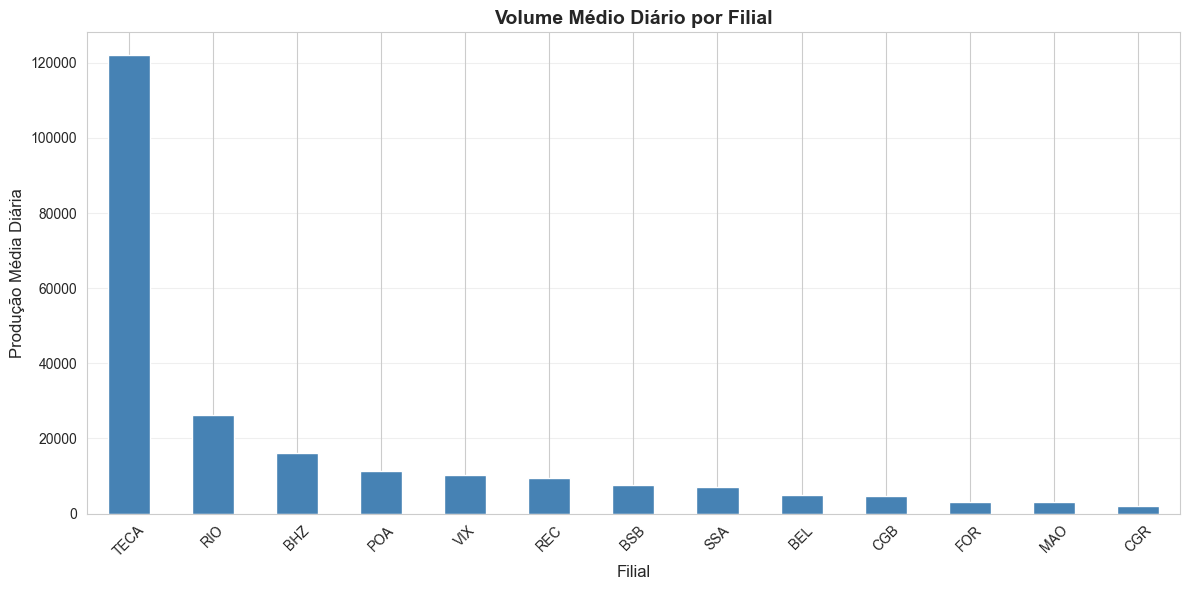

Ranking de volume médio:


,Volume Médio
Filial,
TECA,122030.0
RIO,26374.0
BHZ,16053.0
POA,11292.0
VIX,10193.0
REC,9489.0
BSB,7562.0
SSA,7148.0
BEL,4976.0


In [26]:
### 2.1. Volume médio por filial (ranking)

# Volume médio diário por filial
volume_medio = df.groupby('Filial')['producao'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
volume_medio.plot(kind='bar', color='steelblue')
plt.title('Volume Médio Diário por Filial', fontsize=14, fontweight='bold')
plt.xlabel('Filial', fontsize=12)
plt.ylabel('Produção Média Diária', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Ranking de volume médio:")
display(volume_medio.to_frame('Volume Médio').round(0))


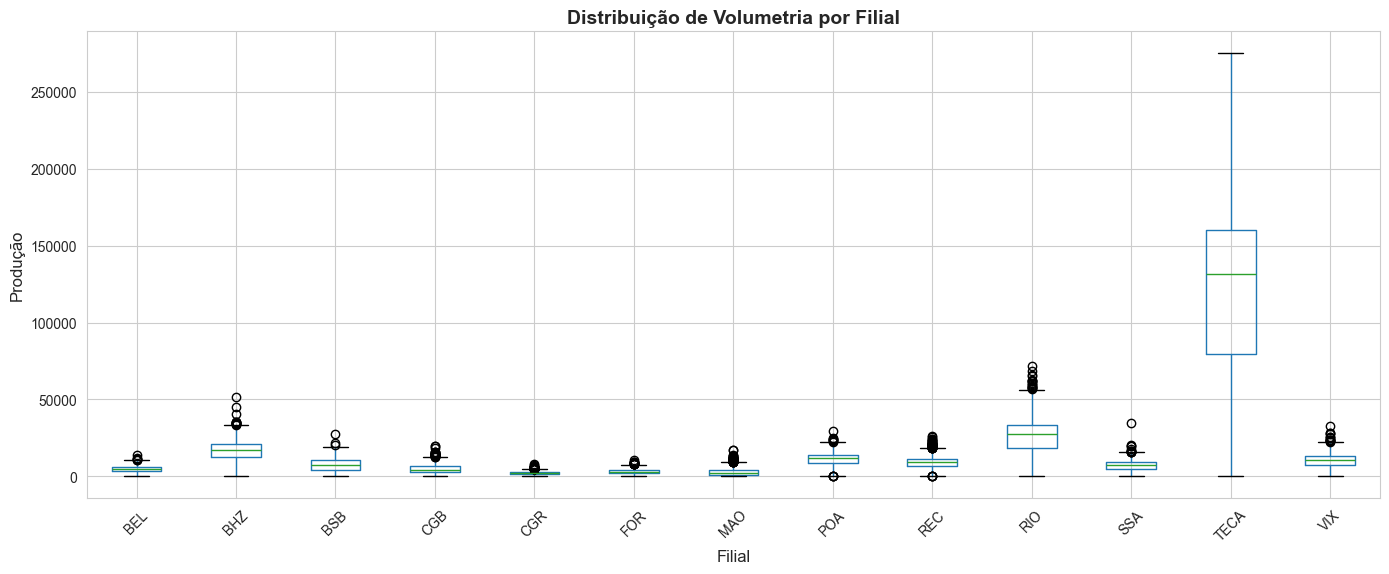

In [27]:
### 2.2. Distribuição de volumetria por filial

# Boxplot por filial
plt.figure(figsize=(14, 6))
df.boxplot(column='producao', by='Filial', ax=plt.gca())
plt.title('Distribuição de Volumetria por Filial', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove título automático
plt.xlabel('Filial', fontsize=12)
plt.ylabel('Produção', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


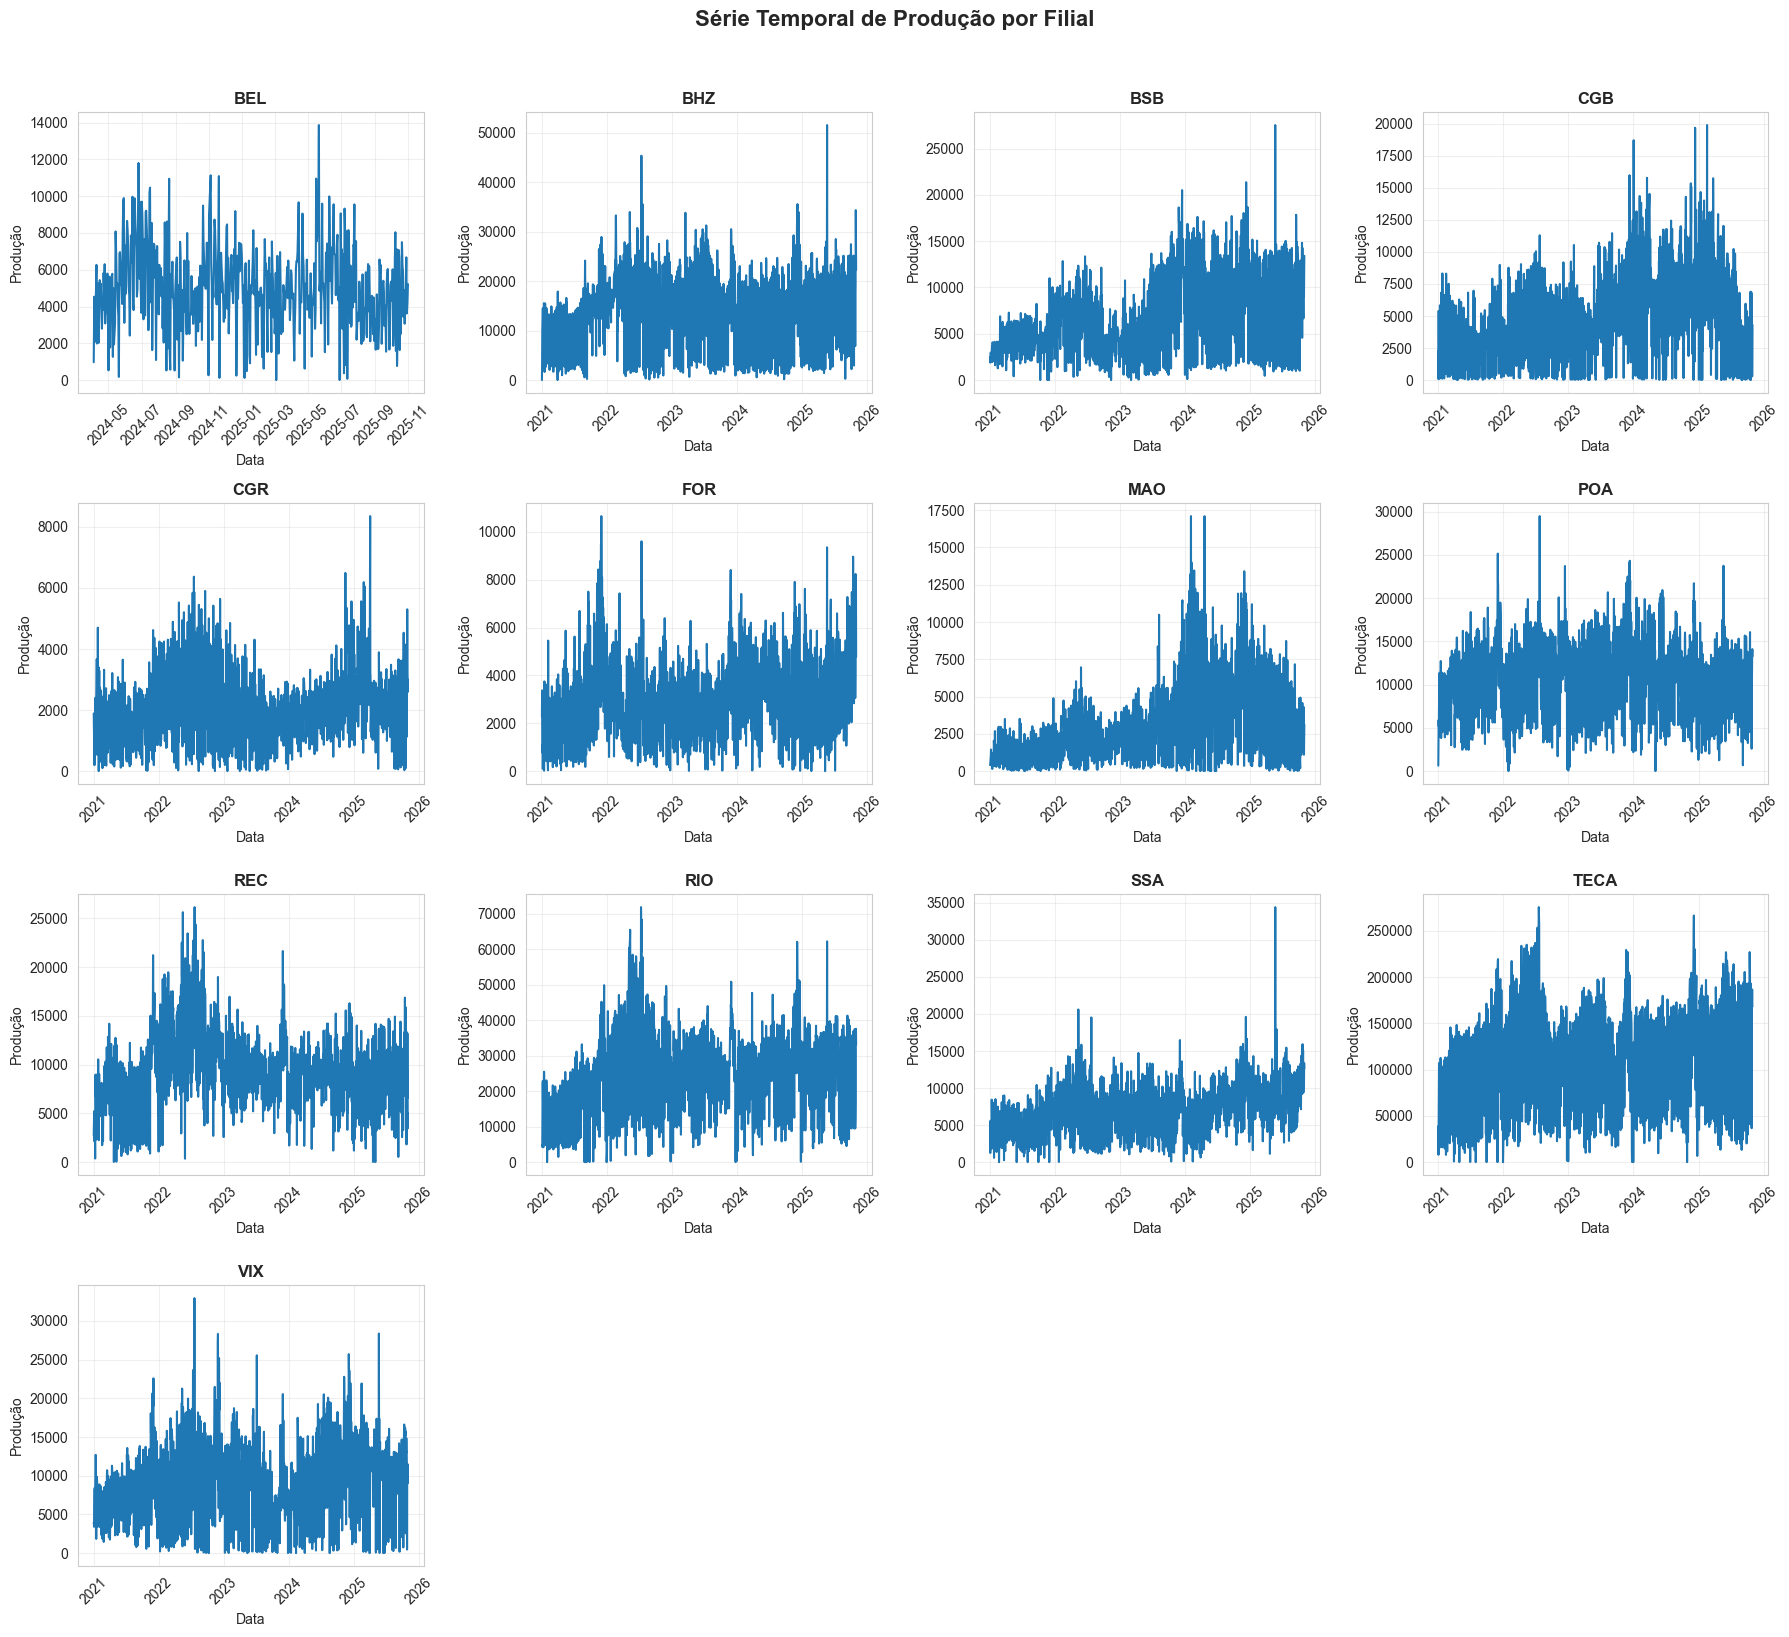

In [28]:
### 2.3. Séries temporais por filial

# Criar subplots para visualizar séries temporais de todas as filiais
filiais_ordenadas = sorted(df['Filial'].dropna().unique())
n_filiais = len(filiais_ordenadas)

# Calcular número de linhas e colunas para subplots
n_cols = 4
n_rows = (n_filiais + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for idx, filial in enumerate(filiais_ordenadas):
    df_filial = df[df['Filial'] == filial].sort_values('Data')
    axes[idx].plot(df_filial['Data'], df_filial['producao'], linewidth=1.5)
    axes[idx].set_title(f'{filial}', fontweight='bold')
    axes[idx].set_xlabel('Data')
    axes[idx].set_ylabel('Produção')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

# Ocultar subplots vazios
for idx in range(n_filiais, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Série Temporal de Produção por Filial', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


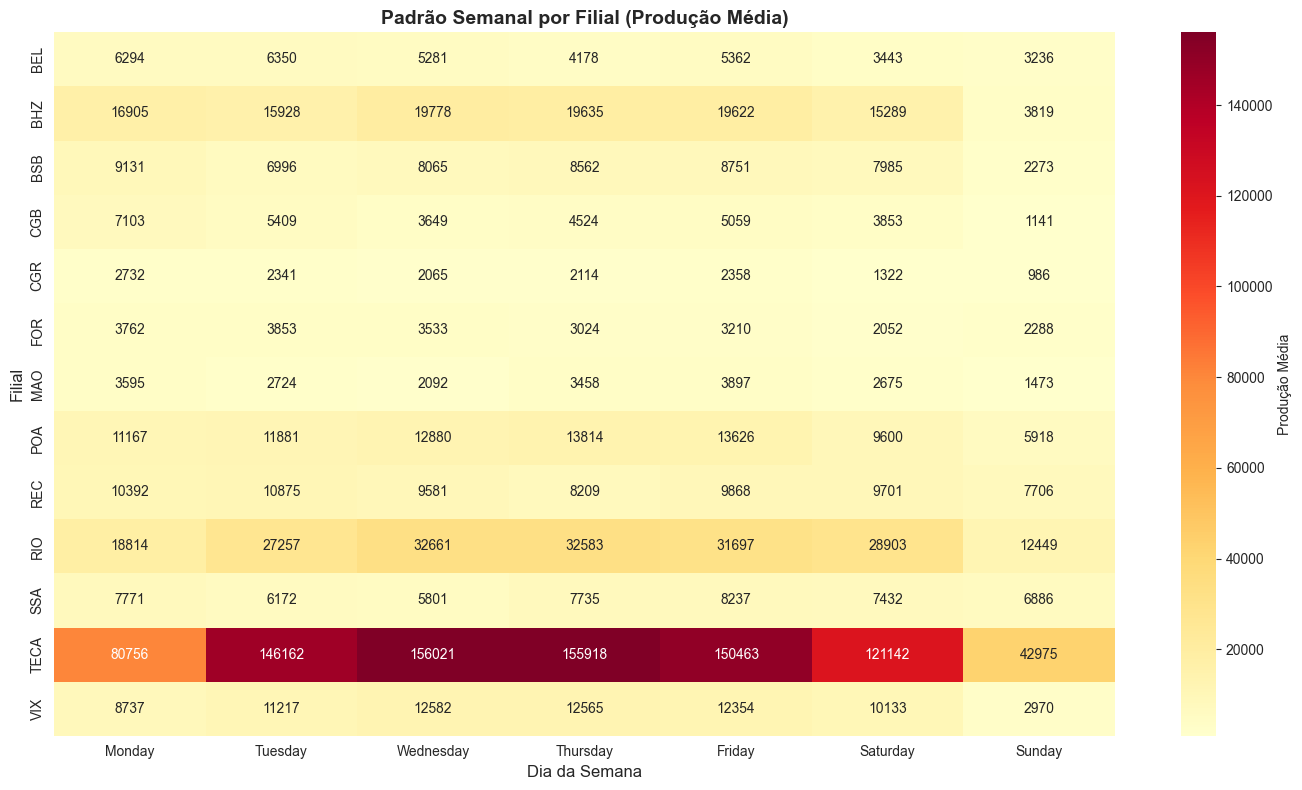

In [29]:
### 2.4. Padrão semanal por filial

# Preparar dados para análise semanal
df['dia_semana_nome'] = df['Data'].dt.day_name()
df['dia_semana_num'] = df['Data'].dt.dayofweek

# Média por dia da semana e filial
media_semanal = df.groupby(['Filial', 'dia_semana_nome'])['producao'].mean().reset_index()
media_semanal_pivot = media_semanal.pivot(index='Filial', columns='dia_semana_nome', values='producao')

# Ordenar colunas por dia da semana
dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
media_semanal_pivot = media_semanal_pivot.reindex(columns=dias_ordem)

# Visualização
plt.figure(figsize=(14, 8))
sns.heatmap(media_semanal_pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Produção Média'})
plt.title('Padrão Semanal por Filial (Produção Média)', fontsize=14, fontweight='bold')
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Filial', fontsize=12)
plt.tight_layout()
plt.show()


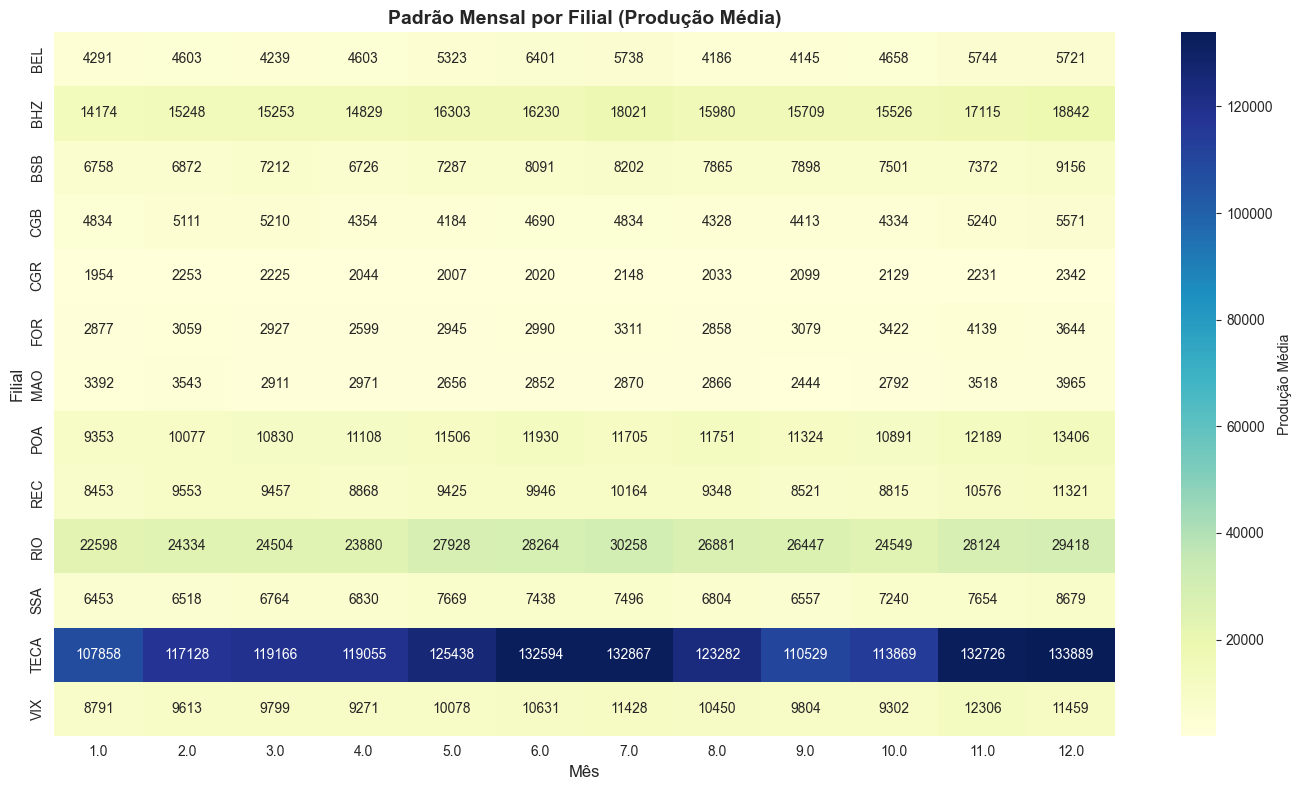

In [30]:
### 2.5. Padrão mensal por filial

# Preparar dados para análise mensal
df['ano'] = df['Data'].dt.year
df['mes'] = df['Data'].dt.month

# Média por mês e filial
media_mensal = df.groupby(['Filial', 'mes'])['producao'].mean().reset_index()
media_mensal_pivot = media_mensal.pivot(index='Filial', columns='mes', values='producao')

# Visualização
plt.figure(figsize=(14, 8))
sns.heatmap(media_mensal_pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Produção Média'})
plt.title('Padrão Mensal por Filial (Produção Média)', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Filial', fontsize=12)
plt.tight_layout()
plt.show()


In [31]:
### 2.6. Impacto de eventos por filial

# Garantir que todas as flags existam e sejam numéricas
flag_cols = [
    'is_holiday', 'is_pre_holiday', 'is_post_holiday',
    'is_black_friday', 'is_christmas', 'is_mothers_day',
    'is_month_start', 'is_month_end',
    'is_pre_bf_dip', 'is_pre_bf_peak', 'is_post_black_friday'
]

for col in flag_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)
    else:
        df[col] = 0

# Comparar médias em dias com/sem cada flag por filial
impacto_flags_filial = {}
for filial in sorted(df['Filial'].dropna().unique()):
    df_filial = df[df['Filial'] == filial]
    impacto_filial = {}
    for col in flag_cols:
        media_flag_1 = df_filial.loc[df_filial[col] == 1, 'producao'].mean()
        media_flag_0 = df_filial.loc[df_filial[col] == 0, 'producao'].mean()
        impacto_filial[col] = {
            'media_flag_1': media_flag_1,
            'media_flag_0': media_flag_0,
            'diferenca_pct': ((media_flag_1 - media_flag_0) / media_flag_0 * 100) if media_flag_0 > 0 else 0
        }
    impacto_flags_filial[filial] = impacto_filial

# Visualizar impacto do Black Friday por filial (exemplo)
bf_impact = pd.DataFrame({
    filial: {
        'Com BF': impacto_flags_filial[filial]['is_black_friday']['media_flag_1'],
        'Sem BF': impacto_flags_filial[filial]['is_black_friday']['media_flag_0'],
        'Diferença %': impacto_flags_filial[filial]['is_black_friday']['diferenca_pct']
    }
    for filial in sorted(df['Filial'].dropna().unique())
}).T

print("Impacto do Black Friday por Filial:")
display(bf_impact.round(2))


Impacto do Black Friday por Filial:


,Com BF,Sem BF,Diferença %
BEL,4617.00,4976.68,-7.23
BHZ,14662.13,16064.91,-8.73
BSB,5512.94,7581.16,-27.28
CGB,3599.94,4746.94,-24.16
CGR,1555.79,2123.42,-26.73
FOR,3030.19,3135.48,-3.36
MAO,1960.20,3054.84,-35.83
POA,9488.69,11309.00,-16.10
REC,10743.50,9477.79,13.35
RIO,22286.00,26414.47,-15.63


<a id="features"></a>
## 3. Engenharia de features (lags por filial + regressores)

Vamos construir o conjunto de variáveis explicativas do modelo:

- **Features de calendário:** ano, mês, dia do mês, dia da semana (numérico, cíclico, one-hot)
- **Flags de eventos:** feriados, Black Friday, Natal, etc.
- **Lags por filial:** produção em D-1, D-2, D-3, D-7, médias móveis

**IMPORTANTE:** Os lags são calculados separadamente por filial para evitar data leakage.


In [32]:
# Função para adicionar features de calendário
def add_calendar_features(df_base):
    """Adiciona features de calendário a um dataframe com coluna 'Data'"""
    df_base = df_base.copy()
    df_base['ano'] = df_base['Data'].dt.year
    df_base['mes'] = df_base['Data'].dt.month
    df_base['dia_mes'] = df_base['Data'].dt.day
    df_base['dia_semana_num'] = df_base['Data'].dt.dayofweek  # 0=Segunda, 6=Domingo
    df_base['dia_semana_nome'] = df_base['Data'].dt.day_name()
    
    # Representações cíclicas
    df_base['dia_semana_sin'] = np.sin(2 * np.pi * df_base['dia_semana_num'] / 7)
    df_base['dia_semana_cos'] = np.cos(2 * np.pi * df_base['dia_semana_num'] / 7)
    df_base['mes_sin'] = np.sin(2 * np.pi * df_base['mes'] / 12)
    df_base['mes_cos'] = np.cos(2 * np.pi * df_base['mes'] / 12)
    
    return df_base

# Aplicar features de calendário
df = add_calendar_features(df)

# One-hot encoding para dias da semana
df_dias = pd.get_dummies(df['dia_semana_nome'], prefix='dia')
df = pd.concat([df, df_dias], axis=1)
dias_cols = list(df_dias.columns)

print("Features de calendário criadas.")
print(f"Colunas de dias da semana: {dias_cols}")


Features de calendário criadas.
Colunas de dias da semana: ['dia_Friday', 'dia_Monday', 'dia_Saturday', 'dia_Sunday', 'dia_Thursday', 'dia_Tuesday', 'dia_Wednesday']


In [33]:
# Calcular lags por filial (IMPORTANTE: separadamente para evitar data leakage)
print("Calculando lags por filial...")

df_model = df.copy().sort_values(['Filial', 'Data']).reset_index(drop=True)

# Para cada filial, calcular lags separadamente
for filial in sorted(df_model['Filial'].dropna().unique()):
    mask_filial = df_model['Filial'] == filial
    df_filial = df_model[mask_filial].copy().sort_values('Data').reset_index(drop=True)
    
    # Lags simples
    df_filial['lag_1'] = df_filial['producao'].shift(1)
    df_filial['lag_2'] = df_filial['producao'].shift(2)
    df_filial['lag_3'] = df_filial['producao'].shift(3)
    df_filial['lag_7'] = df_filial['producao'].shift(7)
    
    # Médias móveis (sem contar o dia atual)
    df_filial['lag_roll_3'] = df_filial['producao'].shift(1).rolling(window=3, min_periods=1).mean()
    df_filial['lag_roll_7'] = df_filial['producao'].shift(1).rolling(window=7, min_periods=1).mean()
    
    # Atualizar no dataframe principal
    df_model.loc[mask_filial, 'lag_1'] = df_filial['lag_1'].values
    df_model.loc[mask_filial, 'lag_2'] = df_filial['lag_2'].values
    df_model.loc[mask_filial, 'lag_3'] = df_filial['lag_3'].values
    df_model.loc[mask_filial, 'lag_7'] = df_filial['lag_7'].values
    df_model.loc[mask_filial, 'lag_roll_3'] = df_filial['lag_roll_3'].values
    df_model.loc[mask_filial, 'lag_roll_7'] = df_filial['lag_roll_7'].values

print("Lags calculados por filial.")

# Remover linhas iniciais sem lags completos (warmup de 7 dias)
df_model = df_model.dropna(subset=['lag_7', 'lag_roll_7']).reset_index(drop=True)

print(f"\nRegistros após remoção de warmup: {len(df_model)}")
print(f"Registros por filial após warmup:")
print(df_model['Filial'].value_counts().sort_index())


Calculando lags por filial...
Lags calculados por filial.

Registros após remoção de warmup: 20534
Registros por filial após warmup:
Filial
BEL      531
BHZ     1709
BSB     1679
CGB     1546
CGR     1510
FOR     1673
MAO     1498
POA     1730
REC     1729
RIO     1735
SSA     1739
TECA    1747
VIX     1708
Name: count, dtype: int64


In [34]:
# Definir lista de features
feature_cols = [
    'ano', 'mes', 'dia_mes', 'dia_semana_num',
    'dia_semana_sin', 'dia_semana_cos',
    'mes_sin', 'mes_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_7',
    'lag_roll_3', 'lag_roll_7',
] + flag_cols + dias_cols

print(f"Total de features: {len(feature_cols)}")
print(f"\nFeatures:")
for i, feat in enumerate(feature_cols, 1):
    print(f"{i:2d}. {feat}")

# Verificar se todas as features existem
missing_features = [f for f in feature_cols if f not in df_model.columns]
if missing_features:
    print(f"\n⚠️ ATENÇÃO: Features faltando: {missing_features}")
else:
    print("\n✓ Todas as features estão presentes no dataset.")


Total de features: 32

Features:
 1. ano
 2. mes
 3. dia_mes
 4. dia_semana_num
 5. dia_semana_sin
 6. dia_semana_cos
 7. mes_sin
 8. mes_cos
 9. lag_1
10. lag_2
11. lag_3
12. lag_7
13. lag_roll_3
14. lag_roll_7
15. is_holiday
16. is_pre_holiday
17. is_post_holiday
18. is_black_friday
19. is_christmas
20. is_mothers_day
21. is_month_start
22. is_month_end
23. is_pre_bf_dip
24. is_pre_bf_peak
25. is_post_black_friday
26. dia_Friday
27. dia_Monday
28. dia_Saturday
29. dia_Sunday
30. dia_Thursday
31. dia_Tuesday
32. dia_Wednesday

✓ Todas as features estão presentes no dataset.


<a id="modelagem"></a>
## 4. Modelagem com tuning de hiperparâmetros por filial

Estratégia:
- Para cada filial, separar treino (até 1 mês antes do fim) e validação (último mês)
- Fazer tuning de hiperparâmetros específico por filial (XGBoost e LightGBM)
- Treinar modelo final com melhores hiperparâmetros
- Armazenar modelos e hiperparâmetros por filial


In [35]:
# Função para avaliar modelo
def eval_model(model, Xtr, ytr, Xva, yva):
    """Treina modelo e retorna métricas de validação"""
    model.fit(Xtr, ytr)
    pred = model.predict(Xva)
    mape = mean_absolute_percentage_error(yva, pred) * 100
    rmse = float(np.sqrt(mean_squared_error(yva, pred)))
    mae = mean_absolute_error(yva, pred)
    return mape, rmse, mae

# Grade de hiperparâmetros (similar ao v4, mas será otimizada por filial)
xgb_param_grid = [
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.8},
    {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 1200, 'max_depth': 12, 'learning_rate': 0.008, 'subsample': 0.9, 'colsample_bytree': 0.9, 'gamma': 0.1, 'min_child_weight': 3},
    {'n_estimators': 1500, 'max_depth': 10, 'learning_rate': 0.005, 'subsample': 0.85, 'colsample_bytree': 0.85, 'gamma': 0.2, 'reg_alpha': 0.1},
    {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.02, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 1.5},
    {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'gamma': 0.05},
]

lgb_param_grid = [
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.8},
    {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 1200, 'max_depth': 12, 'learning_rate': 0.008, 'subsample': 0.9, 'colsample_bytree': 0.9, 'num_leaves': 64, 'min_child_samples': 20},
    {'n_estimators': 1500, 'max_depth': 10, 'learning_rate': 0.005, 'subsample': 0.85, 'colsample_bytree': 0.85, 'num_leaves': 128, 'reg_alpha': 0.1},
    {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.02, 'subsample': 0.7, 'colsample_bytree': 0.7, 'max_bin': 255},
    {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'num_leaves': 32},
]

print("Grades de hiperparâmetros definidas.")
print(f"XGBoost: {len(xgb_param_grid)} combinações")
print(f"LightGBM: {len(lgb_param_grid)} combinações")


Grades de hiperparâmetros definidas.
XGBoost: 10 combinações
LightGBM: 10 combinações


In [36]:
# Dicionários para armazenar resultados
best_params_xgb = {}
best_params_lgb = {}
models_xgb = {}
models_lgb = {}
models_ensemble = {}
tuning_results = {}

# Processar cada filial
filiais_processar = sorted(df_model['Filial'].dropna().unique())
print(f"Processando {len(filiais_processar)} filiais...\n")

for filial in filiais_processar:
    print(f"{'='*60}")
    print(f"Processando filial: {filial}")
    print(f"{'='*60}")
    
    # Separar dados da filial
    df_filial = df_model[df_model['Filial'] == filial].copy().sort_values('Data').reset_index(drop=True)
    
    # Divisão temporal (último mês para validação)
    data_corte = df_filial['Data'].max() - pd.DateOffset(months=1)
    treino = df_filial[df_filial['Data'] <= data_corte].copy()
    valid = df_filial[df_filial['Data'] > data_corte].copy()
    
    if len(treino) < 30 or len(valid) < 7:
        print(f"⚠️ Filial {filial}: dados insuficientes (treino: {len(treino)}, valid: {len(valid)}). Pulando...")
        continue
    
    X_train = treino[feature_cols]
    y_train = treino['producao']
    X_valid = valid[feature_cols]
    y_valid = valid['producao']
    
    print(f"Treino: {len(treino)} registros ({treino['Data'].min().date()} a {treino['Data'].max().date()})")
    print(f"Validação: {len(valid)} registros ({valid['Data'].min().date()} a {valid['Data'].max().date()})")
    
    # Tuning XGBoost
    print("\n--- Tuning XGBoost ---")
    best_xgb = None
    best_xgb_mape = float('inf')
    best_xgb_rmse = None
    
    for params in xgb_param_grid:
        model = XGBRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=42,
            tree_method="hist",
            verbosity=0,
            **{k: v for k, v in params.items() if k not in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']}
        )
        mape, rmse, mae = eval_model(model, X_train, y_train, X_valid, y_valid)
        
        if mape < best_xgb_mape:
            best_xgb_mape = mape
            best_xgb_rmse = rmse
            best_xgb = params.copy()
    
    print(f"Melhor XGBoost - MAPE: {best_xgb_mape:.2f}% | RMSE: {best_xgb_rmse:,.0f}")
    best_params_xgb[filial] = best_xgb
    
    # Tuning LightGBM
    print("\n--- Tuning LightGBM ---")
    best_lgb = None
    best_lgb_mape = float('inf')
    best_lgb_rmse = None
    
    for params in lgb_param_grid:
        model = LGBMRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=42,
            verbosity=-1,
            **{k: v for k, v in params.items() if k not in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']}
        )
        mape, rmse, mae = eval_model(model, X_train, y_train, X_valid, y_valid)
        
        if mape < best_lgb_mape:
            best_lgb_mape = mape
            best_lgb_rmse = rmse
            best_lgb = params.copy()
    
    print(f"Melhor LightGBM - MAPE: {best_lgb_mape:.2f}% | RMSE: {best_lgb_rmse:,.0f}")
    best_params_lgb[filial] = best_lgb
    
    # Treinar modelos finais com todos os dados da filial
    print("\n--- Treinando modelos finais ---")
    X_full = df_filial[feature_cols]
    y_full = df_filial['producao']
    
    xgb_final = XGBRegressor(
        n_estimators=best_xgb['n_estimators'],
        max_depth=best_xgb['max_depth'],
        learning_rate=best_xgb['learning_rate'],
        subsample=best_xgb['subsample'],
        colsample_bytree=best_xgb['colsample_bytree'],
        random_state=42,
        tree_method="hist",
        verbosity=0,
        **{k: v for k, v in best_xgb.items() if k not in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']}
    )
    xgb_final.fit(X_full, y_full)
    models_xgb[filial] = xgb_final
    
    lgb_final = LGBMRegressor(
        n_estimators=best_lgb['n_estimators'],
        max_depth=best_lgb['max_depth'],
        learning_rate=best_lgb['learning_rate'],
        subsample=best_lgb['subsample'],
        colsample_bytree=best_lgb['colsample_bytree'],
        random_state=42,
        verbosity=-1,
        **{k: v for k, v in best_lgb.items() if k not in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']}
    )
    lgb_final.fit(X_full, y_full)
    models_lgb[filial] = lgb_final
    
    # Armazenar resultados de tuning
    tuning_results[filial] = {
        'xgb_mape': best_xgb_mape,
        'xgb_rmse': best_xgb_rmse,
        'lgb_mape': best_lgb_mape,
        'lgb_rmse': best_lgb_rmse
    }
    
    print(f"✓ Filial {filial} processada com sucesso.\n")

print(f"\n{'='*60}")
print(f"Processamento concluído para {len(models_xgb)} filiais.")
print(f"{'='*60}")


Processando 13 filiais...

Processando filial: BEL
Treino: 501 registros (2024-04-11 a 2025-09-30)
Validação: 30 registros (2025-10-01 a 2025-10-31)

--- Tuning XGBoost ---


Melhor XGBoost - MAPE: 49.00% | RMSE: 1,881

--- Tuning LightGBM ---
Melhor LightGBM - MAPE: 49.98% | RMSE: 1,999

--- Treinando modelos finais ---
✓ Filial BEL processada com sucesso.

Processando filial: BHZ
Treino: 1678 registros (2021-01-09 a 2025-09-30)
Validação: 31 registros (2025-10-01 a 2025-10-31)

--- Tuning XGBoost ---
Melhor XGBoost - MAPE: 19.03% | RMSE: 3,529

--- Tuning LightGBM ---
Melhor LightGBM - MAPE: 19.02% | RMSE: 3,827

--- Treinando modelos finais ---
✓ Filial BHZ processada com sucesso.

Processando filial: BSB
Treino: 1648 registros (2021-01-12 a 2025-09-30)
Validação: 31 registros (2025-10-01 a 2025-10-31)

--- Tuning XGBoost ---
Melhor XGBoost - MAPE: 14.04% | RMSE: 1,689

--- Tuning LightGBM ---
Melhor LightGBM - MAPE: 14.45% | RMSE: 1,665

--- Treinando modelos finais ---
✓ Filial BSB processada com sucesso.

Processando filial: CGB
Treino: 1516 registros (2021-01-09 a 2025-09-30)
Validação: 30 registros (2025-10-01 a 2025-10-31)

--- Tuning XGBoost ---
M

<a id="validacao"></a>
## 5. Validação e avaliação

Avaliamos os modelos no conjunto de validação (último mês) para cada filial.


In [37]:
# Avaliar modelos na validação
results_validation = []

for filial in sorted(models_xgb.keys()):
    df_filial = df_model[df_model['Filial'] == filial].copy().sort_values('Data').reset_index(drop=True)
    
    # Divisão temporal
    data_corte = df_filial['Data'].max() - pd.DateOffset(months=1)
    valid = df_filial[df_filial['Data'] > data_corte].copy()
    
    X_valid = valid[feature_cols]
    y_valid = valid['producao']
    
    # Previsões
    pred_xgb = models_xgb[filial].predict(X_valid)
    pred_lgb = models_lgb[filial].predict(X_valid)
    pred_ensemble = (pred_xgb + pred_lgb) / 2
    
    # Métricas
    mape_xgb = mean_absolute_percentage_error(y_valid, pred_xgb) * 100
    rmse_xgb = np.sqrt(mean_squared_error(y_valid, pred_xgb))
    mae_xgb = mean_absolute_error(y_valid, pred_xgb)
    
    mape_lgb = mean_absolute_percentage_error(y_valid, pred_lgb) * 100
    rmse_lgb = np.sqrt(mean_squared_error(y_valid, pred_lgb))
    mae_lgb = mean_absolute_error(y_valid, pred_lgb)
    
    mape_ens = mean_absolute_percentage_error(y_valid, pred_ensemble) * 100
    rmse_ens = np.sqrt(mean_squared_error(y_valid, pred_ensemble))
    mae_ens = mean_absolute_error(y_valid, pred_ensemble)
    
    results_validation.append({
        'Filial': filial,
        'XGB_MAPE': mape_xgb,
        'XGB_RMSE': rmse_xgb,
        'XGB_MAE': mae_xgb,
        'LGB_MAPE': mape_lgb,
        'LGB_RMSE': rmse_lgb,
        'LGB_MAE': mae_lgb,
        'Ensemble_MAPE': mape_ens,
        'Ensemble_RMSE': rmse_ens,
        'Ensemble_MAE': mae_ens
    })

df_results = pd.DataFrame(results_validation)
df_results = df_results.sort_values('Ensemble_MAPE')

print("=== Resultados de Validação por Filial ===")
display(df_results.round(2))


=== Resultados de Validação por Filial ===


,Filial,XGB_MAPE,XGB_RMSE,XGB_MAE,LGB_MAPE,LGB_RMSE,LGB_MAE,Ensemble_MAPE,Ensemble_RMSE,Ensemble_MAE
11,TECA,1.21,2264.22,1624.14,5.16,7989.52,5835.94,3.13,5028.04,3643.49
12,VIX,1.48,123.00,101.63,8.50,960.79,788.76,4.94,534.27,438.93
9,RIO,4.81,1374.72,1022.08,6.79,1844.44,1411.01,5.74,1590.53,1203.86
5,FOR,0.75,53.54,36.27,11.32,727.90,570.93,6.01,386.59,302.33
10,SSA,5.84,787.75,648.41,7.11,963.51,795.64,6.38,851.75,711.63
2,BSB,4.15,423.59,322.00,10.03,827.47,669.37,6.96,609.12,480.65
1,BHZ,1.18,348.66,182.99,14.09,3018.24,2115.61,7.52,1665.81,1141.52
0,BEL,1.99,87.89,70.11,15.39,760.31,559.98,8.66,419.25,314.12
7,POA,8.94,963.74,736.26,10.39,1093.81,800.83,9.62,1022.17,763.02
8,REC,9.18,788.98,673.75,18.23,1487.81,1320.28,13.63,1125.88,988.74


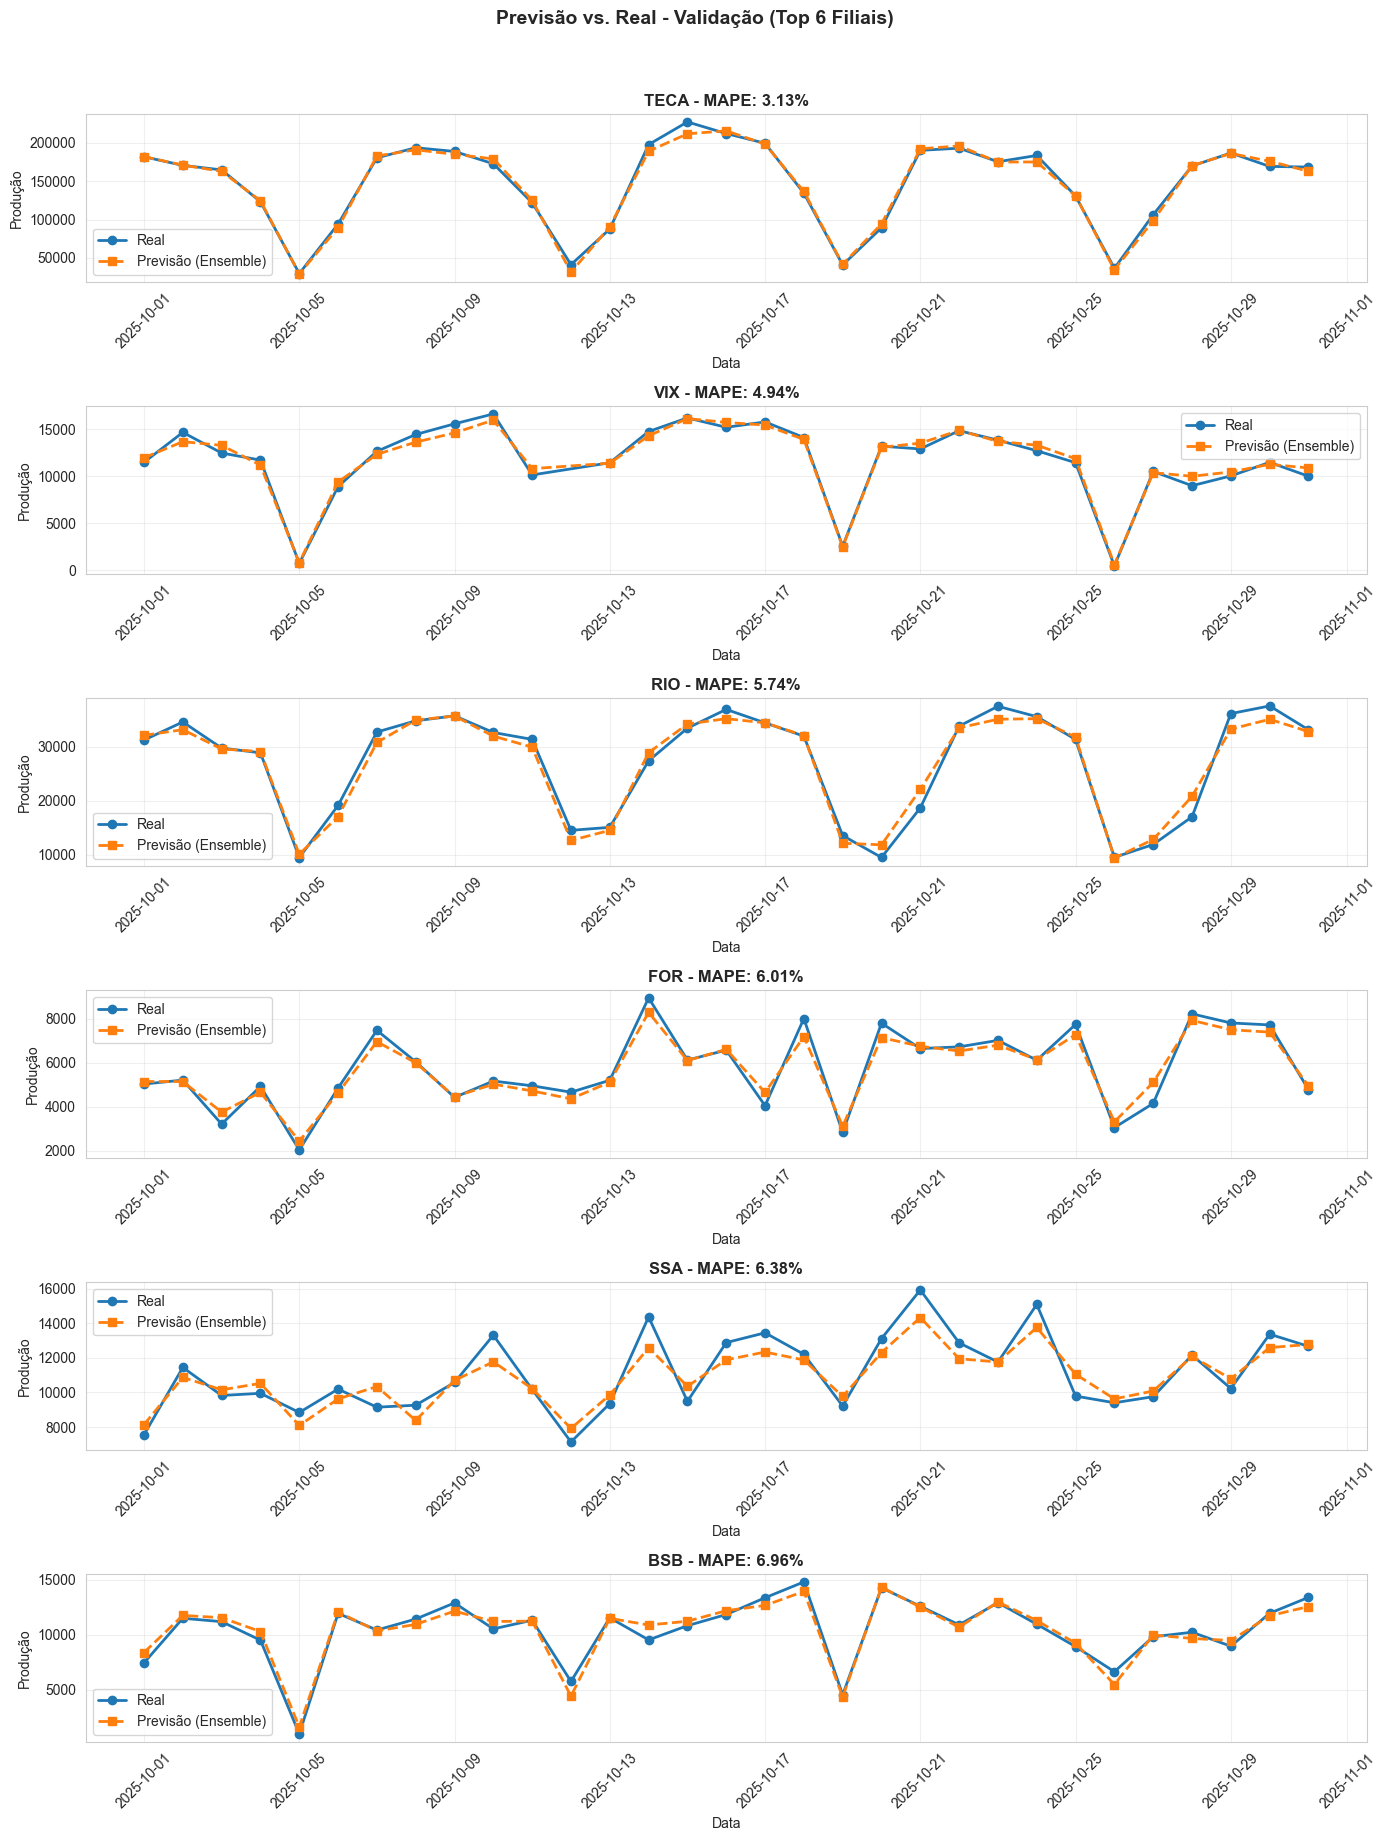

In [38]:
# Visualização: Previsão vs. Real na validação (exemplo para algumas filiais)
filiais_plot = df_results.head(6)['Filial'].tolist()  # Top 6 melhores

n_plot = len(filiais_plot)
fig, axes = plt.subplots(n_plot, 1, figsize=(14, 3*n_plot))

if n_plot == 1:
    axes = [axes]

for idx, filial in enumerate(filiais_plot):
    df_filial = df_model[df_model['Filial'] == filial].copy().sort_values('Data').reset_index(drop=True)
    data_corte = df_filial['Data'].max() - pd.DateOffset(months=1)
    valid = df_filial[df_filial['Data'] > data_corte].copy()
    
    X_valid = valid[feature_cols]
    y_valid = valid['producao']
    pred_ensemble = (models_xgb[filial].predict(X_valid) + models_lgb[filial].predict(X_valid)) / 2
    
    axes[idx].plot(valid['Data'], y_valid, label='Real', marker='o', linewidth=2)
    axes[idx].plot(valid['Data'], pred_ensemble, label='Previsão (Ensemble)', marker='s', linewidth=2, linestyle='--')
    axes[idx].set_title(f'{filial} - MAPE: {df_results[df_results["Filial"]==filial]["Ensemble_MAPE"].values[0]:.2f}%', fontweight='bold')
    axes[idx].set_xlabel('Data')
    axes[idx].set_ylabel('Produção')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Previsão vs. Real - Validação (Top 6 Filiais)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id="previsao"></a>
## 6. Previsão futura (30 dias) com lags recursivos

Para cada filial, geramos previsões para os próximos 30 dias usando forecast recursivo,
onde os lags são calculados dinamicamente usando histórico + previsões anteriores.


In [39]:
# Função para construir features de uma data futura
def build_future_features(data_prev, cal_df, historico_filial, feature_cols):
    """
    Constrói features para uma data futura, incluindo lags calculados do histórico.
    
    Args:
        data_prev: Data a ser prevista
        cal_df: DataFrame com calendário
        historico_filial: Lista/array com valores históricos da filial (últimos valores)
        feature_cols: Lista de nomes das features
    
    Returns:
        DataFrame com uma linha contendo todas as features
    """
    # Buscar informações do calendário
    linha_cal = cal_df[cal_df['Data'] == data_prev].copy()
    if len(linha_cal) == 0:
        # Se não encontrar no calendário, criar linha básica
        linha_cal = pd.DataFrame({'Data': [data_prev]})
        for col in flag_cols:
            linha_cal[col] = 0
    
    # Adicionar features de calendário
    linha_cal = add_calendar_features(linha_cal)
    
    # One-hot encoding para dias da semana
    linha_cal['dia_semana_nome'] = linha_cal['Data'].dt.day_name()
    df_dias = pd.get_dummies(linha_cal['dia_semana_nome'], prefix='dia')
    linha_cal = pd.concat([linha_cal, df_dias], axis=1)
    
    # Garantir todas as colunas de dias
    for col in dias_cols:
        if col not in linha_cal.columns:
            linha_cal[col] = 0
    
    # Garantir flags numéricas
    for col in flag_cols:
        if col not in linha_cal.columns:
            linha_cal[col] = 0
        linha_cal[col] = linha_cal[col].fillna(0).astype(int)
    
    # Calcular lags do histórico
    if len(historico_filial) >= 7:
        linha_cal['lag_1'] = historico_filial[-1]
        linha_cal['lag_2'] = historico_filial[-2] if len(historico_filial) >= 2 else historico_filial[-1]
        linha_cal['lag_3'] = historico_filial[-3] if len(historico_filial) >= 3 else historico_filial[-1]
        linha_cal['lag_7'] = historico_filial[-7] if len(historico_filial) >= 7 else historico_filial[-1]
        linha_cal['lag_roll_3'] = np.mean(historico_filial[-3:]) if len(historico_filial) >= 3 else historico_filial[-1]
        linha_cal['lag_roll_7'] = np.mean(historico_filial[-7:]) if len(historico_filial) >= 7 else np.mean(historico_filial)
    else:
        # Fallback se histórico insuficiente
        valor_medio = np.mean(historico_filial) if len(historico_filial) > 0 else 0
        linha_cal['lag_1'] = valor_medio
        linha_cal['lag_2'] = valor_medio
        linha_cal['lag_3'] = valor_medio
        linha_cal['lag_7'] = valor_medio
        linha_cal['lag_roll_3'] = valor_medio
        linha_cal['lag_roll_7'] = valor_medio
    
    # Garantir todas as features
    for col in feature_cols:
        if col not in linha_cal.columns:
            linha_cal[col] = 0
    
    return linha_cal[feature_cols]

print("Função de construção de features futuras criada.")


Função de construção de features futuras criada.


In [40]:
# Previsão futura para todas as filiais
ultima_data = df_model['Data'].max()
dias_futuro = 30
datas_futuras = pd.date_range(start=ultima_data + pd.Timedelta(days=1), periods=dias_futuro, freq='D')

print(f"Última data histórica: {ultima_data.date()}")
print(f"Previsão para: {datas_futuras[0].date()} a {datas_futuras[-1].date()} ({dias_futuro} dias)")
print(f"\nProcessando previsões para {len(models_xgb)} filiais...\n")

# Preparar calendário futuro
cal_futuro = cal[cal['Data'].isin(datas_futuras)].copy()
if len(cal_futuro) < len(datas_futuras):
    # Se faltar datas no calendário, criar DataFrame completo
    cal_futuro = pd.DataFrame({'Data': datas_futuras})
    cal_futuro = cal_futuro.merge(cal, on='Data', how='left')
cal_futuro.columns = [c.strip().replace('\xa0', '') for c in cal_futuro.columns]

previsoes_futuras = []

for filial in sorted(models_xgb.keys()):
    print(f"Processando filial: {filial}...")
    
    # Obter histórico da filial
    df_filial = df_model[df_model['Filial'] == filial].copy().sort_values('Data').reset_index(drop=True)
    historico_filial = df_filial['producao'].values.tolist()
    
    previsoes_filial = []
    
    for data_prev in datas_futuras:
        # Construir features
        X_pred = build_future_features(data_prev, cal_futuro, historico_filial, feature_cols)
        
        # Prever
        pred_xgb = models_xgb[filial].predict(X_pred)[0]
        pred_lgb = models_lgb[filial].predict(X_pred)[0]
        pred_ensemble = (pred_xgb + pred_lgb) / 2
        
        previsoes_filial.append({
            'Data': data_prev,
            'Filial': filial,
            'prev_xgb': pred_xgb,
            'prev_lgb': pred_lgb,
            'prev_ensemble': pred_ensemble
        })
        
        # Atualizar histórico para próximo lag (usar ensemble)
        historico_filial.append(pred_ensemble)
    
    previsoes_futuras.extend(previsoes_filial)
    print(f"  ✓ {filial} concluída")

df_previsoes = pd.DataFrame(previsoes_futuras)
df_previsoes = df_previsoes.sort_values(['Filial', 'Data']).reset_index(drop=True)

print(f"\n✓ Previsões geradas para {len(df_previsoes)} registros ({len(models_xgb)} filiais × {dias_futuro} dias)")
df_previsoes.head(10)


Última data histórica: 2025-10-31
Previsão para: 2025-11-01 a 2025-11-30 (30 dias)

Processando previsões para 13 filiais...

Processando filial: BEL...
  ✓ BEL concluída
Processando filial: BHZ...
  ✓ BHZ concluída
Processando filial: BSB...
  ✓ BSB concluída
Processando filial: CGB...
  ✓ CGB concluída
Processando filial: CGR...
  ✓ CGR concluída
Processando filial: FOR...
  ✓ FOR concluída
Processando filial: MAO...
  ✓ MAO concluída
Processando filial: POA...
  ✓ POA concluída
Processando filial: REC...
  ✓ REC concluída
Processando filial: RIO...
  ✓ RIO concluída
Processando filial: SSA...
  ✓ SSA concluída
Processando filial: TECA...
  ✓ TECA concluída
Processando filial: VIX...
  ✓ VIX concluída

✓ Previsões geradas para 390 registros (13 filiais × 30 dias)


,Data,Filial,prev_xgb,prev_lgb,prev_ensemble
0,2025-11-01,BEL,3138.596191,3156.485894,3147.541043
1,2025-11-02,BEL,3175.704590,3343.662152,3259.683371
2,2025-11-03,BEL,5287.106445,5271.303943,5279.205194
3,2025-11-04,BEL,4743.820312,3817.261192,4280.540752
4,2025-11-05,BEL,5113.780762,5672.822066,5393.301414
5,2025-11-06,BEL,3227.351562,3721.144997,3474.248280
6,2025-11-07,BEL,4515.039062,5891.121995,5203.080529
7,2025-11-08,BEL,2645.244629,2837.206388,2741.225509
8,2025-11-09,BEL,3008.628174,3163.694266,3086.161220
9,2025-11-10,BEL,5295.536621,5253.967500,5274.752060


<a id="storytelling"></a>
## 7. Storytelling e visualizações finais

Criamos visualizações para comunicar os resultados de forma clara e acionável.


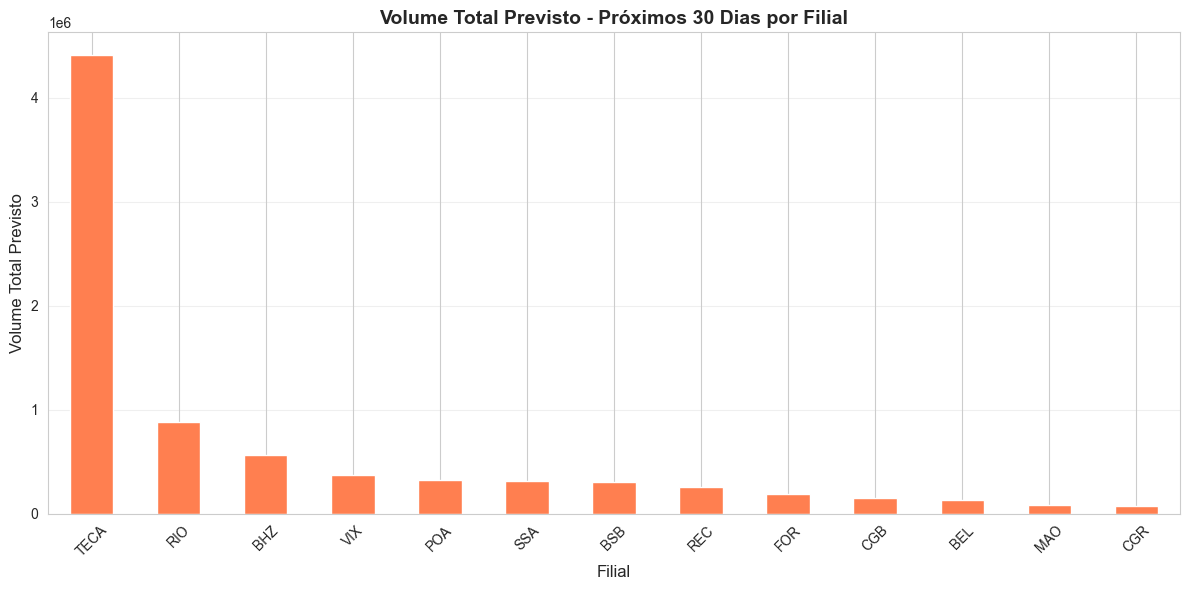

Volume total previsto (30 dias):


,Volume Total
Filial,
TECA,4408458.0
RIO,880735.0
BHZ,568038.0
VIX,371626.0
POA,320575.0
SSA,312691.0
BSB,306712.0
REC,251679.0
FOR,189207.0


In [41]:
### 7.1. Volume total previsto por filial (próximos 30 dias)

volume_total_previsto = df_previsoes.groupby('Filial')['prev_ensemble'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
volume_total_previsto.plot(kind='bar', color='coral')
plt.title('Volume Total Previsto - Próximos 30 Dias por Filial', fontsize=14, fontweight='bold')
plt.xlabel('Filial', fontsize=12)
plt.ylabel('Volume Total Previsto', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Volume total previsto (30 dias):")
display(volume_total_previsto.to_frame('Volume Total').round(0))


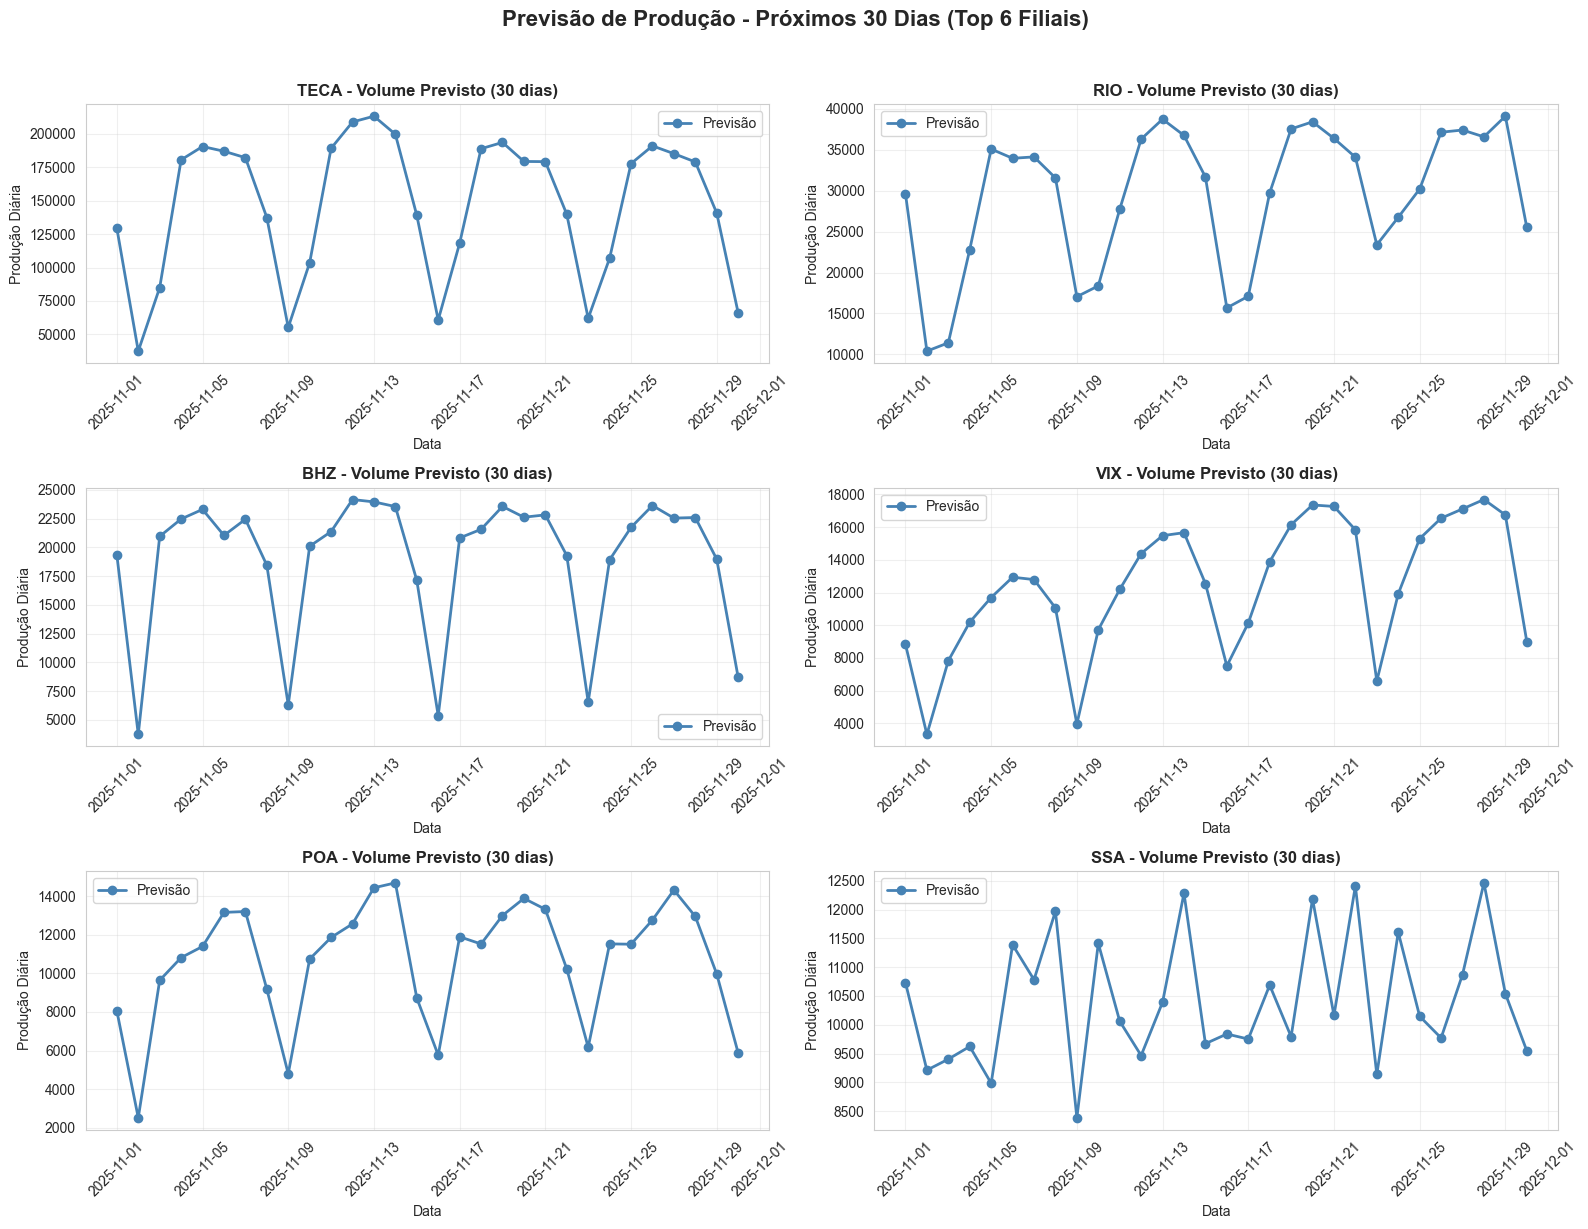

In [42]:
### 7.2. Série temporal de previsão por filial

# Selecionar algumas filiais para visualização (top 6 por volume)
top_filiais = volume_total_previsto.head(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, filial in enumerate(top_filiais):
    df_prev_filial = df_previsoes[df_previsoes['Filial'] == filial].sort_values('Data')
    axes[idx].plot(df_prev_filial['Data'], df_prev_filial['prev_ensemble'], 
                   marker='o', linewidth=2, label='Previsão', color='steelblue')
    axes[idx].set_title(f'{filial} - Volume Previsto (30 dias)', fontweight='bold')
    axes[idx].set_xlabel('Data')
    axes[idx].set_ylabel('Produção Diária')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Previsão de Produção - Próximos 30 Dias (Top 6 Filiais)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [43]:
### 7.3. Insights e recomendações

print("="*70)
print("INSIGHTS E RECOMENDAÇÕES")
print("="*70)

# Top 3 filiais por volume previsto
top3_volume = volume_total_previsto.head(3)
print(f"\n📊 TOP 3 FILIAIS POR VOLUME PREVISTO (30 dias):")
for i, (filial, volume) in enumerate(top3_volume.items(), 1):
    print(f"  {i}. {filial}: {volume:,.0f} unidades")

# Filiais com melhor performance (menor MAPE)
top3_mape = df_results.nsmallest(3, 'Ensemble_MAPE')[['Filial', 'Ensemble_MAPE']]
print(f"\n✅ TOP 3 FILIAIS COM MELHOR PRECISÃO (menor MAPE):")
for i, row in top3_mape.iterrows():
    print(f"  {i+1}. {row['Filial']}: MAPE {row['Ensemble_MAPE']:.2f}%")

# Filiais com pior performance
bottom3_mape = df_results.nlargest(3, 'Ensemble_MAPE')[['Filial', 'Ensemble_MAPE']]
print(f"\n⚠️  TOP 3 FILIAIS COM MENOR PRECISÃO (maior MAPE):")
for i, row in bottom3_mape.iterrows():
    print(f"  {i+1}. {row['Filial']}: MAPE {row['Ensemble_MAPE']:.2f}%")

# Volume médio diário previsto
volume_medio_diario = df_previsoes.groupby('Filial')['prev_ensemble'].mean().sort_values(ascending=False)
print(f"\n📈 VOLUME MÉDIO DIÁRIO PREVISTO (30 dias):")
print(f"  Maior: {volume_medio_diario.index[0]} ({volume_medio_diario.iloc[0]:,.0f} unidades/dia)")
print(f"  Menor: {volume_medio_diario.index[-1]} ({volume_medio_diario.iloc[-1]:,.0f} unidades/dia)")

print("\n" + "="*70)
print("RECOMENDAÇÕES OPERACIONAIS:")
print("="*70)
print("1. Priorizar planejamento de mão de obra para filiais com maior volume previsto")
print("2. Monitorar filiais com maior MAPE para identificar possíveis melhorias no modelo")
print("3. Considerar sazonalidade e eventos especiais (Black Friday, Natal) no planejamento")
print("4. Revisar previsões periodicamente e ajustar modelos conforme necessário")
print("="*70)


INSIGHTS E RECOMENDAÇÕES

📊 TOP 3 FILIAIS POR VOLUME PREVISTO (30 dias):
  1. TECA: 4,408,458 unidades
  2. RIO: 880,735 unidades
  3. BHZ: 568,038 unidades

✅ TOP 3 FILIAIS COM MELHOR PRECISÃO (menor MAPE):
  12. TECA: MAPE 3.13%
  13. VIX: MAPE 4.94%
  10. RIO: MAPE 5.74%

⚠️  TOP 3 FILIAIS COM MENOR PRECISÃO (maior MAPE):
  4. CGB: MAPE 1090.60%
  5. CGR: MAPE 72.90%
  7. MAO: MAPE 56.31%

📈 VOLUME MÉDIO DIÁRIO PREVISTO (30 dias):
  Maior: TECA (146,949 unidades/dia)
  Menor: CGR (2,416 unidades/dia)

RECOMENDAÇÕES OPERACIONAIS:
1. Priorizar planejamento de mão de obra para filiais com maior volume previsto
2. Monitorar filiais com maior MAPE para identificar possíveis melhorias no modelo
3. Considerar sazonalidade e eventos especiais (Black Friday, Natal) no planejamento
4. Revisar previsões periodicamente e ajustar modelos conforme necessário


<a id="exportacao"></a>
## 8. Exportação dos resultados

Exportamos as previsões futuras e, opcionalmente, métricas e hiperparâmetros por filial.


In [44]:
# Exportar previsões futuras
output_path = "forecast_next_30_days_multivariado.csv"
df_previsoes_export = df_previsoes[['Data', 'Filial', 'prev_ensemble', 'prev_xgb', 'prev_lgb']].copy()
df_previsoes_export.columns = ['Data', 'Filial', 'Previsao_Ensemble', 'Previsao_XGBoost', 'Previsao_LightGBM']
df_previsoes_export.to_csv(output_path, sep=';', index=False, decimal=',')
print(f"✓ Previsões futuras exportadas para: {output_path}")

# Exportar métricas de validação
output_metrics = "metricas_validacao_multivariado.csv"
df_results_export = df_results.copy()
df_results_export.to_csv(output_metrics, sep=';', index=False, decimal=',')
print(f"✓ Métricas de validação exportadas para: {output_metrics}")

# Exportar hiperparâmetros por filial
output_params = "hiperparametros_por_filial.csv"
params_list = []
for filial in sorted(best_params_xgb.keys()):
    params_list.append({
        'Filial': filial,
        'Modelo': 'XGBoost',
        **best_params_xgb[filial]
    })
    params_list.append({
        'Filial': filial,
        'Modelo': 'LightGBM',
        **best_params_lgb[filial]
    })
df_params = pd.DataFrame(params_list)
df_params.to_csv(output_params, sep=';', index=False, decimal=',')
print(f"✓ Hiperparâmetros exportados para: {output_params}")

print("\n" + "="*70)
print("EXPORTAÇÃO CONCLUÍDA")
print("="*70)
print(f"Arquivos gerados:")
print(f"  1. {output_path}")
print(f"  2. {output_metrics}")
print(f"  3. {output_params}")
print("="*70)


PermissionError: [Errno 13] Permission denied: 'forecast_next_30_days_multivariado.csv'